# Foundations: Wavelet Transform

## Motivation
- We want to analyze audio signals 
- Need to know **what** frequencies are present and **when** they occur - this is the primary motivation for finding a method for highly accurate **time-frequency** analysis 
- The standard approach is to use the **Fourier Transform**, but it has limitations in this context
- The **Wavelet Transform** is much better suited for this kind of task
- Both are built upon the same foundation - **signal decomposition** 
- Beginning with simple examples, we will build up to a comprehensive and intuitive understanding of how the Fourier and Wavelet Transform are used to decompose signals, and explore the different areas where each transform excels and falls short

## Signal Decomposition
- The end goal is to take an aribitrary signal and decompose it into its **fundamental components**
- In simpler terms, we want to break down a composite signal into its basic **building blocks** and determine how much of each exists in the overall signal 
- It's like trying to unmix a can of paint to figure out how much of each color ingredient contributed to the overall color of the paint - where would you even begin?
- This type of problem motivates us to find a way to do two things:
    1. **Define what a signal's fundamental components are** 
    2. **Measure how much of each component is present in the signal** 
- This is where the **Inner Product** comes into play - it's a general-purpose tool for measuring components present in a signal, and we will explore these two motivations in different contexts

### Inner Product 
- Accomplishing signal decomposition really depends on the signal being analyzed and the type of properties present in the signal we are interested in discovering 
- The **Inner Product** gives us a quantitative way to calculate a "similarity score" between a function **f** and a reference function **g** 

<div align="center">

$$
\langle \, 
\mathbf{f} \, , \, 
\mathbf{g} \,
\rangle 
$$

<em>Inner Product Notation</em>

</div>

- The result is a measurement of how aligned the two functions are, reflecting their similarity
- Eventually we will bridge the gap for audio contexts where 
    - The **function** being analyzed is an **audio signal** 
    - The **reference function** has **time-frequency properties** we are interesting in measuring 
    - The Inner Product is performed on a signal and a set of reference functions (sometimes called a basis) to measure how much of each of those properties are in the overall signal
- Before getting into bases, , we are starting with the simplest form of the Inner Product: the **Dot Product** has a nice geometric visualization

### Dot Product

- The Inner Product is a generalization of what the **Dot Product** does to **vectors** in $\mathbb{R}$ (domain for all **R**eal Numbers)
- For now we are just sticking with real, regular numbers - no imaginary numbers (yet) or weird abstract numbers in weird abstract math domains

<div align="center">

$$
\vec{a} \cdot\vec{b} = \sum_{i=0}^{n} a_i b_i
$$

<em>Dot Product Notation</em>
</div>

- The Dot Product is typically taught in the early chapters of Vector Calculus, but as long as you know basic **multiplication** and **addition**, it's really not too bad
- If you have two vectors **a** and **b**
    - Take the first term from **a** 
    - And take the first term from **b**
    - **Multiply** them together
    - Repeat for the second terms, the third terms, and so on... until the final terms
    - Finally, **add** them all up

<div align="center">

$$
\vec{a} = 
    ( \,
    a_0 \, , \,
    a_1 \, , \,
    a_2 \, , \, 
    \ldots \, , \,
    a_n \, )
$$

</div>

<div align="center">

$$
\vec{b} = 
    ( \,
    b_0 \, , \,
    b_1 \, , \,
    b_2 \, , \, 
    \ldots \, , \,
    b_n \, )
$$

</div>

<div align="center">

$$
\vec{a} \cdot\vec{b} = 
    a_0 \cdot b_0 \, + \,
    a_1 \cdot b_1 \, + \,
    a_2 \cdot b_2 \, + \, 
    \ldots \, + \,
    a_n \cdot b_n \, 
$$

<em> Dot Product Operation </em>
</div>

### Vector Projection
- We'll be using these terms a lot so to brush up on our basic calculus, every **vector** looks like an **arrow**, each having a 
    - **magnitude** - how long it is (a single / scalar value, always positive)

    - **direction** - where it points (its angle / orientation in space)

        <img src="figures/basic_vector_arrow.png" alt="2D Vectors" width="200">
        
        *Figure: Basic Vector*

- What does the Dot Product do?
    1. Takes a pair of vectors
    2. Performs a set of operations on them, using their magnitudes and directions
    3. Produces a scalar result 

- Geometric Interpretation 
    - Geometrically, the Dot Product tells us how parallel the two vectors are
    - We can all agree that a pair of **parallel** vectors appear more **similar** than a **non-parallel** pair
    - Even if the parallel vectors' lengths (magnitudes) are different, the result still implies these vectors are aligned in the same direction, reflecting their alikeness

- For two vectors **a** and **b**
    - parallel + same direction = strongly similar = positive result
    - parallel + opposite direction = strongly opposite = negative result
    - perpendicular / perfectly un-parallel = no similarity / unrelated = zero result

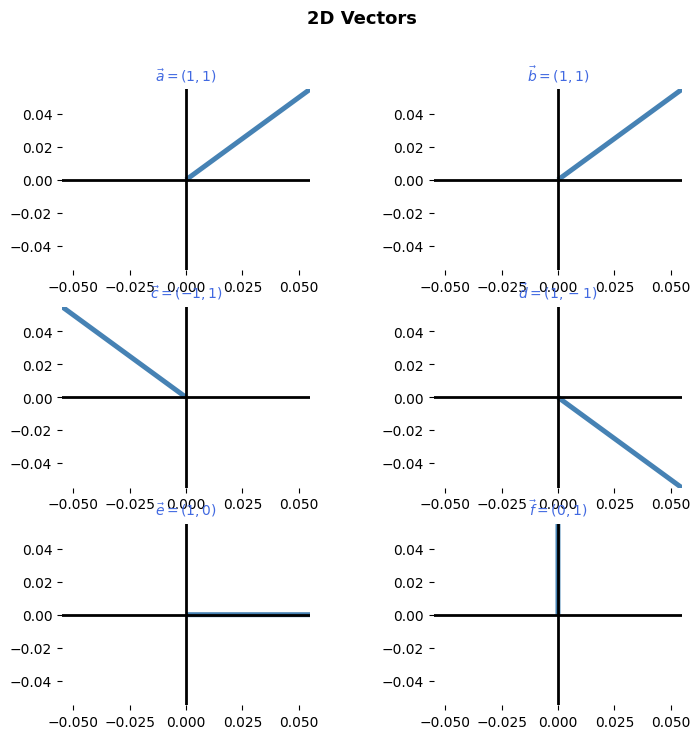

In [1]:
import numpy as np
from plot_vectors import plot_vectors

vectors = [
    np.array([1, 1]),
    np.array([1, 1]),
    np.array([-1, 1]),
    np.array([1, -1]),
    np.array([1, 0]),
    np.array([0, 1]),
]

plot_vectors(vectors, "vectors_parallel_perpendicular_2x3")


    *[Graphic: Visualize Parallel Same Direction, Parallel Opposite Direction, and Perpindicular Vectors]*

    - What if these vectors were **oblique** (neither completely parallel nor completely perpindicular)?
        - oblique + any direction = potentially kind of similar or not that similar

        *[Graphic: Oblique Vectors - one kind of similar, one not so similar]*

    - So how does it do that exactly? 
        - Well if we took one vector's orientation, and composed the other vector using the dimensions of the first, we can see that the second vector can be composed of two basic vectors, one of them being largely parallel with the other, visually showing us why we can say the second vector is very similar to the first one, but the third one is not so similar
    - This is the heart of the Dot Product and is formally called Vector Projection

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import numpy as np
import os

vectors = [
    (2,  1),    
    (1,  2),
    (-2, -1),
    (1, -2),
]

labels = [
    rf'$\vec{{{chr(97+i)}}} = ({x}, {y})$'
    for i, (x, y) in enumerate(vectors)
]

fig = plt.figure(figsize=(14, 3.5))
gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.5)

for i, ((x, y), label) in enumerate(zip(vectors, labels)):
    ax = fig.add_subplot(gs[0, i])

    lim = max(abs(x), abs(y)) + 1
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xticks(range(-lim, lim + 1))
    ax.set_yticks(range(-lim, lim + 1))
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

    ax.axhline(0, color='gray', linewidth=0.8, zorder=0)
    ax.axvline(0, color='gray', linewidth=0.8, zorder=0)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_aspect('equal')

    ax.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1,
              color='royalblue', width=0.01)

    ax.set_title(label, fontsize=10, color='royalblue')
    ax.tick_params(labelsize=8)
    ax.set_xlabel('x', fontsize=9)
    ax.set_ylabel('y', fontsize=9, rotation=0)

plt.suptitle('2D Vectors', fontsize=13, fontweight='bold')
figures_dir = './figures'
os.makedirs(figures_dir, exist_ok=True)
plt.savefig(os.path.join(figures_dir, 'vectors.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

vectors = [
    np.array([-1, 1]),
    np.array([-0.5, 0.5]),
    np.array([-0.5, -1]),
    np.array([1.5, -0.3]),
]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

lim = 1.5

for ax, v in zip(axes, vectors):
    ax.axhline(0, color='black', linewidth=2)
    ax.axvline(0, color='black', linewidth=2)

    ax.quiver(0, 0, v[0], v[1], 
        angles='xy', scale_units='xy', scale=1,
        color='steelblue',
        alpha=1,
        width=0.02,
        headwidth=3, 
        headlength=3, 
        headaxislength=3)

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle('2D Vectors', fontsize=13, fontweight='bold')


plt.tight_layout()
plt.show()